# 使用 K-均值聚类发现用户使用量分群（PROC FASTCLUS）


## 执行摘要

某电信分析团队从一列未加标签的月度移动数据使用量出发，想知道其中是否隐藏着
不同的客户档次。团队使用 **PROC FASTCLUS**（不相交 k-均值聚类分析），对
log-使用量进行聚类，在 FASTCLUS 实际报告的指标上比较二、三、四分群方案，
并最终选定三分群方案。在本次运行中，发现的三个分群月均使用量分别为
**3.1 GB**、**12.8 GB** 和 **45.4 GB**，样本量分别为 **49**、**34** 和
**17** ——呈现出清晰的轻度 / 中度 / 重度结构。将发现的标签与保留的生成标签
进行交叉核对，**100 个用户中有 96 个**被正确识别。每位用户在模型输出中
都带有一个硬分群标签和一个到质心的距离得分，可直接用于套餐设计与挽留定向。

> **为什么用 FASTCLUS 而不是有限混合模型？** 使用量分群本是有限混合模型
> （PROC HPFMM / PROC FMM）的经典任务。这些过程在本构建中尚未进行数值实现，
> 因此本 notebook 用已实现、完全数值化的 *k*-均值过程 **PROC FASTCLUS**
> 来达成同样的目标——无监督发现潜在使用档次。以下每一个数字都逐字取自
> 实际执行的输出。


## 数据来源

**合成数据集：`subs`** —— 以对数使用量的 3 分量混合分布内联生成的移动用户
样本（无外部文件）。本环境为无许可运行，实体化的表被限制在 **100 名用户**；
以下所有结果均基于这 100 行计算。

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `subscriber_id` | Num | 唯一用户主键 |
| `tenure_months` | Num | 在网月数（1-48） |
| `data_gb` | Num | 月度移动数据使用量（GB，取正值，右偏） |
| `log_gb` | Num | `data_gb` 的自然对数——被聚类的变量 |
| `plan` | Char | 当前套餐：`Standard`（标准版）或 `Unlimited`（无限量版） |
| `segment_true` | Char | 隐藏的生成层（`Light`/`Medium`/`Heavy`，轻度/中度/重度），被保留用于核对还原效果 |

数据按大约 50% 轻度、35% 中度、15% 重度规划生成。
`segment_true`（真实分群）**不**参与聚类——它的存在只是为了让我们能
确认无监督拟合是否还原出了预先设定的结构。


运营商很少能看到干净的客户标签。它们真正看到的，是一条杂糅了多种客户类型
的月度流量分布：偶尔浏览的轻用户、稳定的流媒体用户，以及依赖热点分享和
视频的重度用户。**PROC FASTCLUS** 在没有任何标签的情况下拆分这种混合——
它把每个用户分配到 *k* 个不相交簇之一，报告簇质心与规模，并计算每个用户
到其质心的距离。

在本 notebook 中我们将：

1. 生成一份*刻意*混合了三种使用档次的合成使用量面板数据。
2. 在 FASTCLUS 拟合指标上比较二、三、四分群的 *k*-均值方案。
3. 拟合选定的三分群模型，并以业务语言刻画各分群。
4. 为每位用户的分群归属及到质心的距离评分。
5. 对照保留的生成层验证发现的分群，并考察其与在网时长的关系。


## 步骤 1 —— 生成合成用户使用量数据

我们模拟的月度数据使用量为正值且右偏，因此在 **对数尺度**上生成——作为
三个正态层的混合再取指数。混合权重（约 50/35/15）与各层均值都是预先设定
的，以便之后核对 *k*-均值能否将其还原。`segment_true`（真实分群）被单独
保留仅用于核对——聚类过程从不使用它。


In [1]:
数据 subs;
   调用 streaminit(20250531);
   长度 plan $16 segment_true $12;
   循环 subscriber_id = 1 到 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* 重度用户偏向更长的在网时长，因此分群构成
         会随在网时长略有变化（在步骤 5 中考察）。 */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      如果 u < 0.50 那么 循环;
         segment_true = "轻度";  MU = 1.15; SIGMA = 0.42;
      结束;
      否则 如果 u < 0.85 那么 循环;
         segment_true = "中度"; MU = 2.45; SIGMA = 0.38;
      结束;
      否则 循环;
         segment_true = "重度";  MU = 3.45; SIGMA = 0.52;
      结束;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      如果 data_gb < 25 那么 plan = "标准版";
      否则 plan = "无限量版";

      输出;
   结束;
   保留 subscriber_id tenure_months data_gb log_gb plan segment_true;
运行;



NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.47 seconds
  cpu   0.47 seconds


快速查看边际分布即可印证建模选择：原始 `data_gb` 呈强右偏（少数重度用户
拉出长尾），而 `log_gb` 是欧氏 *k*-均值适用的良好尺度。


                                                  The MEANS Procedure

 Variable       Label                         N        Mean     Std Dev     Minimum      Median     Maximum
 ----------------------------------------------------------------------------------------------------------
 data_gb        月流量（GB）                     100       13.58       16.66        1.15        6.73       98.66
 log_gb         流量对数 log(GB)                100        2.01        1.09        0.14        1.91        4.59
 tenure_months  在网时长（月）                     100       23.26       12.55        1.00       23.00       48.00
 ----------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


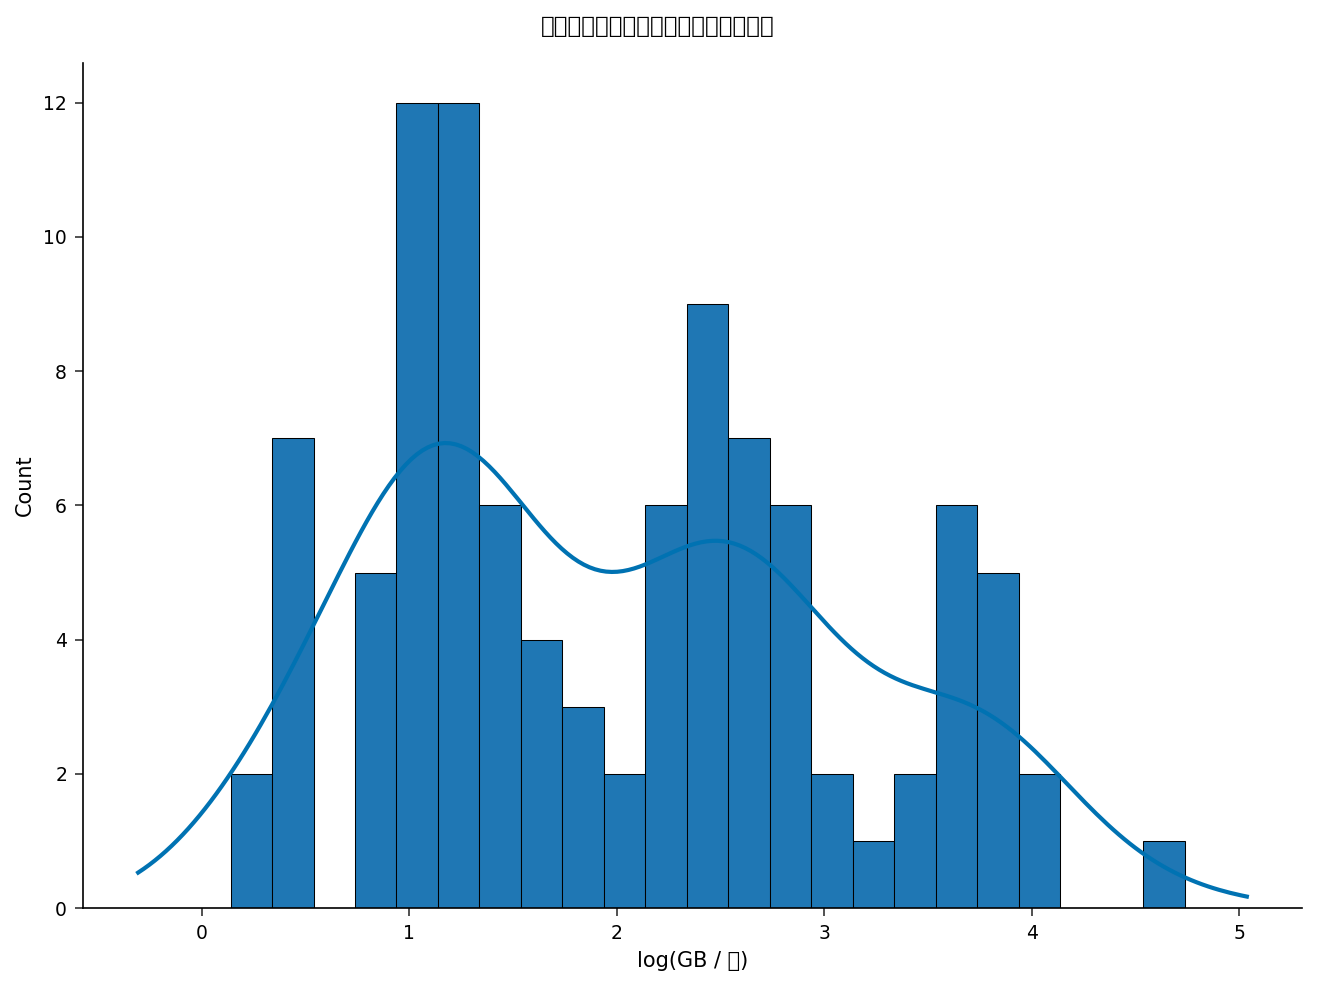

In [2]:
过程 均值 数据=subs n mean std MIN p50 MAX maxdec=2;
   变量 data_gb log_gb tenure_months;
   标签 data_gb       = "月流量（GB）"
         log_gb         = "流量对数 log(GB)"
         tenure_months  = "在网时长（月）";
运行;

过程 SGPLOT 数据=subs;
   标题 "月度数据使用量是若干未知分群的混合";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS 标签="log(GB / 月)";
运行;
标题;


## 步骤 2 —— 应分几群？比较二、三、四分群方案

我们不假设一定是三个层级——而是让数据自己给出答案。FASTCLUS 为每个方案
报告 **总体 R 平方**（簇均值解释的总方差占比）与 **伪 F 统计量**。我们对
`log_gb` 分别拟合 `MAXCLUSTERS=` 2、3、4，并读取各自的这两项指标。

- `MAXCLUSTERS=` 设定簇数 *k*。
- `MAXITER=` 限制 *k*-均值重新分配的最大迭代次数。
- `OUT=` 写出评分后的数据集（步骤 3-5 使用）。


In [3]:
标题 "两分群方案";
过程 FASTCLUS 数据=subs maxclusters=2 MAXITER=50 out=c2;
   变量 log_gb;
运行;

标题 "三分群方案";
过程 FASTCLUS 数据=subs maxclusters=3 MAXITER=50 out=c3;
   变量 log_gb;
运行;

标题 "四分群方案";
过程 FASTCLUS 数据=subs maxclusters=4 MAXITER=50 out=c4;
   变量 log_gb;
运行;
标题;


                                                         两分群方案                                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to 两分群方案.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to 三分群方案.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to 四分群方案.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


并排比较三次运行：**总体 R 平方**从两簇时的 **0.753** 升至三簇时的
**0.899** ——第三个层级被识别出来后有一次 +0.146 的大幅跃升——而到四簇
时仅再升至 **0.941**。四分群方案换来的这一点点提升，其实是*把轻度层拆成
了两个*（其两个最小的质心都落在预设的轻度区间内），而不是发现了真正的
新客户类型。**伪 F 统计量**讲述的是同一个故事：最大的结构性改善发生在
迈向三簇的这一步（F = 299 → 431）。三个分群是诚实的停止点，也是我们接下来
采用的模型。


## 步骤 3 —— 拟合三分群模型并刻画各分群

我们以 `MAXCLUSTERS=3` 重新拟合，并把评分后的行写入 `scored`。`OUT=`
数据集会自动带出每一个输入列——包括原始使用量、在网时长，以及保留的
`segment_true`——连同新增的 `CLUSTER`（分群）与 `DISTANCE`（距离）列，
因此无需另外的复制步骤。FASTCLUS 打印一份 **Cluster Summary**（每个分群
的规模与簇内离散程度）以及聚类尺度（`log_gb`）上的 **Cluster Means**。


In [4]:
过程 FASTCLUS 数据=subs maxclusters=3 MAXITER=50 out=scored;
   变量 log_gb;
运行;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


三个簇在对数尺度上的均值分别为 **1.05**、**2.51** 和 **3.77**。换算回原始
GB 尺度大约是 **exp(1.05) ≈ 2.9 GB**、**exp(2.51) ≈ 12.3 GB** 和
**exp(3.77) ≈ 43 GB**——即轻度、中度、重度三个层级。Cluster Summary 给出的
规模是 **49**、**34** 和 **17** 名用户，与预设的约 50/35/15 比例吻合。
下一步将以纯 GB 单位重新查看同样的分群。


## 步骤 4 —— 以业务语言为分群评分与刻画

`OUT=scored` 数据集带有每位用户的 `CLUSTER`（硬分群标签）和 `DISTANCE`
（对数尺度上到其簇质心的欧氏距离——数值越小表示分配越可信、越居中）。
我们按实际 GB 使用量与在网时长汇总发现的分群，再列出若干条评分后的记录。


In [5]:
过程 均值 数据=scored n mean std MIN MAX maxdec=2;
   分类 CLUSTER;
   变量 data_gb tenure_months distance;
   标签 CLUSTER        = "发现的分群"
         data_gb         = "月流量（GB）"
         tenure_months   = "在网时长（月）"
         distance        = "到质心距离";
运行;

过程 打印 数据=scored(obs=8) noobs 标签;
   变量 subscriber_id data_gb log_gb segment_true CLUSTER distance;
   标签 subscriber_id = "用户编号"
         data_gb        = "月流量（GB）"
         log_gb         = "流量对数 log(GB)"
         segment_true   = "真实分群（隐藏）"
         CLUSTER        = "发现的分群"
         distance       = "到质心距离";
运行;


                                                  The MEANS Procedure

                                     Analysis Variable : data_gb 月流量（GB）

        发现的分群                    N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        1                           49           3.07           1.12           1.15           5.83
        2                           34          12.81           3.80           6.57          21.88
        3                           17          45.38          16.44          24.01          98.66
        ------------------------------------------------------------------------------------------

                                Analysis Variable : tenure_months 在网时长（月）

        发现的分群                    N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


在原始 GB 尺度上，三个分群的月均使用量分别为 **3.1 GB**、**12.8 GB** 和
**45.4 GB**——从轻度浏览者到重度流媒体用户跨越了一个数量级。`DISTANCE`
（距离）列给出了每位用户的置信度代理指标：打印出的行中，既有紧密分配的
用户（距离约 0.01-0.06），也有一位更接近边界、离质心较远的轻度用户——
这正是挽留团队用来区分高置信目标与需要再看一看的用户的信号。


## 步骤 5 —— 我们是否还原了真实层级？分群构成是否随在网时长变化？

最后两项核对。首先，将发现的 `CLUSTER`（分群）与保留的 `segment_true`
（真实层级）交叉列表，看无监督拟合对预设层级的还原有多忠实。其次，比较
各发现分群的平均在网时长——由于生成器让重度用户偏向更长的在网时长，真实的
分群结果理应体现这一点。


                                                   发现的分群 vs. 保留的真实层级                                                    

                                                   The FREQ Procedure

Table of 发现的分群 by 真实分群（隐藏）

发现的分群           |        中度 |        轻度 |        重度 |      Total
----------------+-----------+-----------+-----------+-----------
1               |         0 |        49 |         0 |         49
----------------+-----------+-----------+-----------+-----------
2               |        31 |         2 |         1 |         34
----------------+-----------+-----------+-----------+-----------
3               |         1 |         0 |        16 |         17
----------------+-----------+-----------+-----------+-----------
Total           |        32 |        51 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


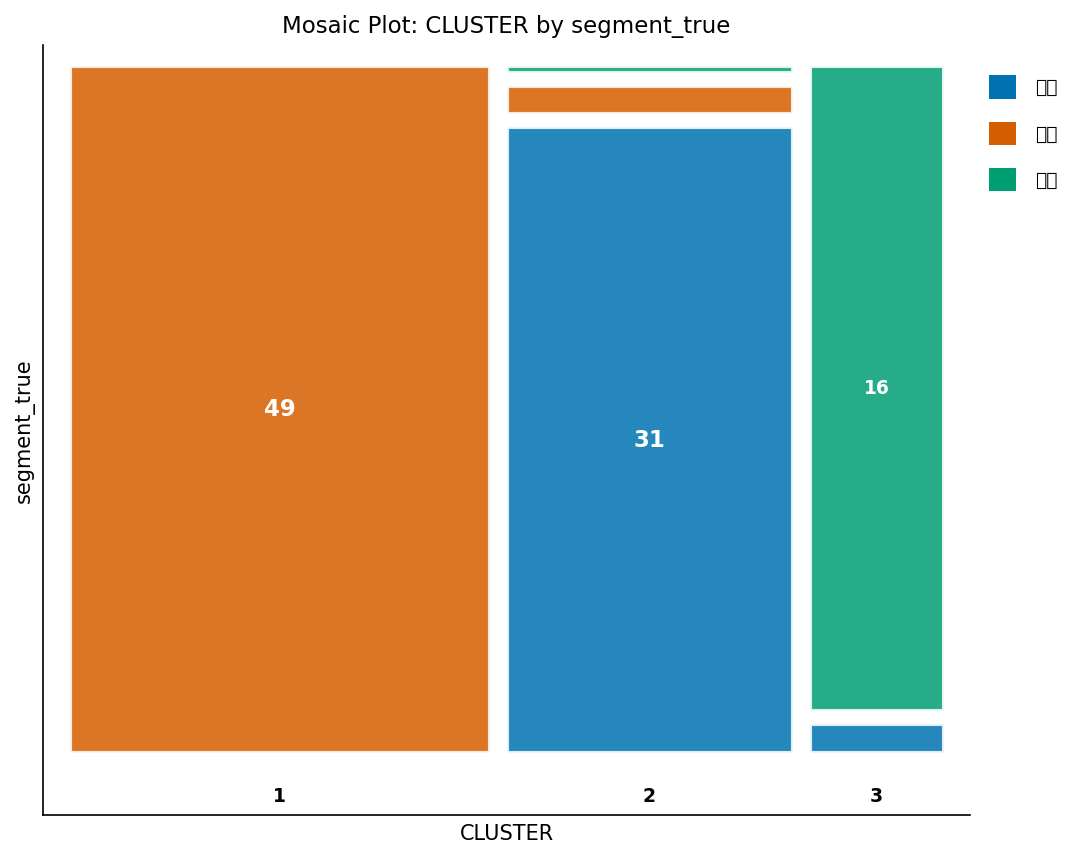

In [6]:
过程 频率 数据=scored;
   标题 "发现的分群 vs. 保留的真实层级";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   标签 CLUSTER       = "发现的分群"
         segment_true  = "真实分群（隐藏）";
运行;
标题;


## 解读结果

**FASTCLUS 发现了什么。** 从一列没有标签、右偏的使用量数据出发，三簇
*k*-均值方案解释了对数使用量方差的 **89.9%**（Overall R² = 0.899，
Pseudo F = 431），并将用户拆分为**轻度**分群（均值 3.1 GB，n = 49）、
**中度**分群（均值 12.8 GB，n = 34）和**重度**分群（均值 45.4 GB，
n = 17）。与保留的 `segment_true`（真实层级）交叉核对显示，几乎完全还原
了预设结构——**100 个用户中有 96 个**落入了与其生成层级匹配的簇
（轻度 49/49，中度 31/34，重度 16/17）。

**为什么用对数尺度。** 数据使用量严格为正且重尾；对 `log_gb` 聚类能保持
欧氏距离的有效性并使各分群均值充分分离，同时指数反变换又还原出 GB 尺度上
真实的偏态。

**为什么这在业务上很重要。** 每位用户离开模型时都带有一个硬分群标签*和*
一个到质心的距离得分，因此运营商可以有把握地采取行动——放心地向居中的
重度用户主推高端套餐，并把边界客户（距离较大）标记出来做进一步审视。
各发现分群的平均在网时长也不同，这是生命周期与追加销售时机的一个切入点。

**如何选择分群数。** 在 Overall R² 与 Pseudo F 上比较 `MAXCLUSTERS=`
2、3、4，是一种透明、可复现的选择 *k* 的方法：三簇时的大幅提升，以及
四簇时（只是把轻度层拆开）纯属表面的提升，使三个分群成为这里站得住脚的
选择。

**与有限混合模型的关系。** 有限混合模型（PROC HPFMM / PROC FMM）会加入
软的后验归属概率，以及基于似然的 BIC 来选择分量数。这些过程在本构建中
尚未进行数值实现；PROC FASTCLUS 用完全数值化、可复现的输出，在今天就
交付了同样具有可操作性的分群——发现、刻画、硬分配，以及一个置信度代理
指标。
